# 实验3：定价模型对比（对应论文图10）

本notebook复现论文图10，对比三种定价模型：
1. 所提模型（Stackelberg博弈）
2. 平均定价模型
3. 随机定价模型

预期结果：
- 所提模型：约40次迭代收敛，总效益约5.72
- 平均模型：约15次迭代收敛，总效益约2
- 随机模型：不收敛，大幅波动
- 所提模型优于平均模型约286%

**数据源**：EUA Dataset (Melbourne CBD) — `/Experiment/data/eua-dataset/`

In [1]:
# ============ 可调参数 ============
N_OWNERS = 5                  # 数据所有者数量
SEED = 42                     # 随机种子
P_MAX = 10.0                  # 最高价格
X_MIN = 0.0                   # 最小购买量
X_MAX = 15.0                  # 最大购买量
MU = 0.01                     # 梯度步长
MAX_ITER = 250                # 最大迭代次数（真实数据需更多迭代收敛）
TOL = 1e-6                    # 收敛阈值

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from data_loader import load_eua_data, sample_owners, create_consumer
from quality_model import compute_quality
from stackelberg_model import run_stackelberg
from baseline_models import run_random_pricing, run_average_pricing

# 准备数据
df = load_eua_data()
owners = sample_owners(df, n_owners=N_OWNERS, seed=SEED)
consumer = create_consumer(-37.81, 144.96, 30.0)
Q_raw = compute_quality(owners, consumer, 10.0, 60.0, 0.5)
# 缩放Q值到论文实际使用的量级（论文图7中Q值为1.98~9.53，远超[0,1]）
Q = Q_raw * 10.0
c = owners['cost'].values

print('Q:', Q)
print('c:', c)

# 运行三个模型
res_stackelberg = run_stackelberg(Q, c, p_max=P_MAX, x_min=X_MIN, x_max=X_MAX,
                                   mu=MU, max_iter=MAX_ITER, tol=TOL)
res_random = run_random_pricing(Q, c, p_max=P_MAX, x_min=X_MIN, x_max=X_MAX,
                                 max_iter=MAX_ITER, seed=123)
res_average = run_average_pricing(Q, c, p_max=P_MAX, x_min=X_MIN, x_max=X_MAX,
                                   max_iter=MAX_ITER, seed=SEED)

Q: [4.8411543  7.56817413 8.271249   4.93889606 8.45659558]
c: [1.50133661 0.75847981 0.78843353 0.56130292 0.75340259]


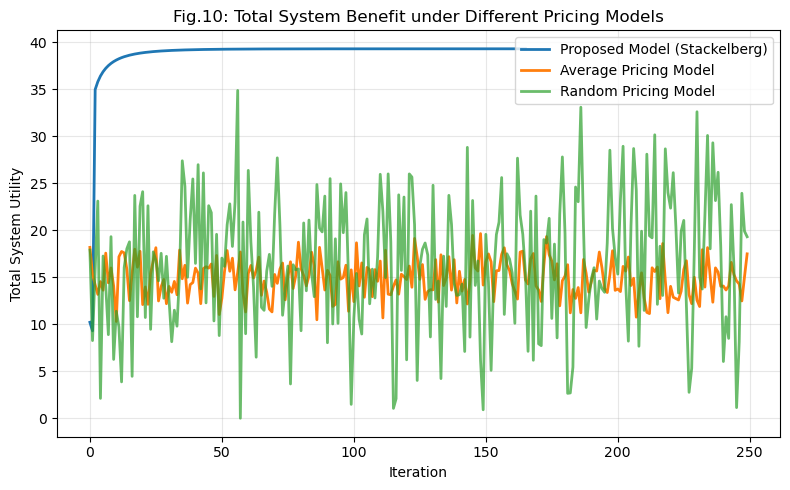

Stackelberg稳态效益: 39.32
Average稳态效益: 14.76


In [3]:
# 图10：三种定价模型下系统总效益对比
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res_stackelberg['total_utility_history'], label='Proposed Model (Stackelberg)', linewidth=2)
ax.plot(res_average['total_utility_history'], label='Average Pricing Model', linewidth=2)
ax.plot(res_random['total_utility_history'], label='Random Pricing Model', linewidth=2, alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Total System Utility')
ax.set_title('Fig.10: Total System Benefit under Different Pricing Models')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 打印关键数据
print(f'Stackelberg稳态效益: {res_stackelberg["total_utility_history"][-1]:.2f}')
print(f'Average稳态效益: {np.mean(res_average["total_utility_history"][-10:]):.2f}')